# Hepatocyte Clinical Associations

This notebook regenerates the separate panels used for Figure 3. All panels use the pre-specified exp_decay, 0.5 Mb, spearman_r_linear_resid setup, with visible labels standardised to `FOXA2+` and `FOXA2-`.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import fisher_exact, chi2_contingency

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 8,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
})

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'outputs' / 'thesis').exists():
    ROOT = ROOT.parent

FIG_DIR = ROOT / 'outputs/thesis/03_hepatocyte_clinical_associations/figures'
SUMMARY_DIR = ROOT / 'outputs/thesis/03_hepatocyte_clinical_associations/data'

RANKINGS_PATH = SUMMARY_DIR / 'source_validation_score_rankings.csv'
CLINICAL_PATH = SUMMARY_DIR / 'source_clinical_labels.csv'
ADJ_GROUP_TESTS_PATH = SUMMARY_DIR / 'source_validation_group_tests_mutation_burden_adjusted.csv'
FIG_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_TRACK = 'exp_decay'
PRIMARY_BIN = 500000.0
PRIMARY_METRIC = 'spearman_r_linear_resid'
PRIMARY_CONFIG = f'track_strategy={PRIMARY_TRACK}|bin_size={PRIMARY_BIN}'
STATE_ORDER = ['FOXA2+', 'FOXA2-']
STATE_PALETTE = {'FOXA2+': '#1f77b4', 'FOXA2-': '#ff7f0e'}
GROUP_PALETTE = {'no': '#d97865', 'yes': '#2a9d8f'}

rankings = pd.read_csv(RANKINGS_PATH)
clinical = pd.read_csv(CLINICAL_PATH)
adj_group_tests = pd.read_csv(ADJ_GROUP_TESTS_PATH)

selected = rankings[
    (rankings['config_id'] == PRIMARY_CONFIG)
    & (rankings['scoring_system'] == PRIMARY_METRIC)
].copy()
selected['sample_id_short'] = selected['sample'].astype(str).str.slice(0, 15)
selected['assigned_state'] = selected['best_cell_state'].map({
    'foxa2_normal_pos': 'FOXA2+',
    'foxa2_abnormal_zero': 'FOXA2-',
})

clinical['sample_id'] = clinical['sample_id'].astype(str).str.strip()
analysis_df = selected.merge(clinical, left_on='sample_id_short', right_on='sample_id', how='left')
analysis_df['obesity_binary'] = pd.Series(np.nan, index=analysis_df.index, dtype='object')
obesity_lower = analysis_df['obesity_class'].astype(str).str.lower()
analysis_df.loc[obesity_lower.eq('normal') | obesity_lower.eq('underweight'), 'obesity_binary'] = 'not_overweight'
analysis_df.loc[obesity_lower.eq('overweight') | obesity_lower.str.startswith('obesity class'), 'obesity_binary'] = 'overweight'
analysis_df['event'] = analysis_df['vital_status'].astype(str).str.upper().eq('DECEASED')
analysis_df['time_days'] = np.where(analysis_df['event'], analysis_df['days_to_death'], analysis_df['days_to_last_followup'])
analysis_df['time_years'] = analysis_df['time_days'].astype(float) / 365.25

adj_group_tests_primary = adj_group_tests[
    (adj_group_tests['config_id'] == PRIMARY_CONFIG)
    & (adj_group_tests['scoring_system'] == PRIMARY_METRIC)
].copy()

print('Primary setup:', PRIMARY_CONFIG, PRIMARY_METRIC)
print('Selected samples:', analysis_df['sample'].nunique())


Primary setup: track_strategy=exp_decay|bin_size=500000.0 spearman_r_linear_resid
Selected samples: 68


## 1) FOXA2 State Distribution

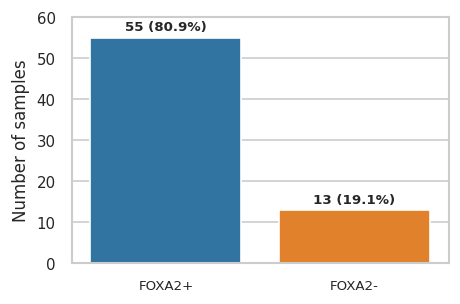

In [2]:
state_counts = (
    analysis_df['assigned_state']
    .value_counts()
    .reindex(STATE_ORDER)
    .rename_axis('assigned_state')
    .reset_index(name='n_samples')
)
state_counts['pct'] = 100.0 * state_counts['n_samples'] / state_counts['n_samples'].sum()
state_counts.to_csv(SUMMARY_DIR / '01_state_distribution_best_setup.csv', index=False)

fig, ax = plt.subplots(figsize=(4.0, 2.7))
sns.barplot(
    data=state_counts,
    x='assigned_state',
    y='n_samples',
    hue='assigned_state',
    order=STATE_ORDER,
    hue_order=STATE_ORDER,
    palette=STATE_PALETTE,
    legend=False,
    ax=ax,
)
for i, row in state_counts.iterrows():
    ax.text(i, row['n_samples'] + 1.0, f"{int(row['n_samples'])} ({row['pct']:.1f}%)", ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Number of samples')
ax.set_ylim(0, 60)
fig.tight_layout()
fig.savefig(FIG_DIR / '01_state_distribution_selected_setup.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


## 2) Label-Based Sensitivity

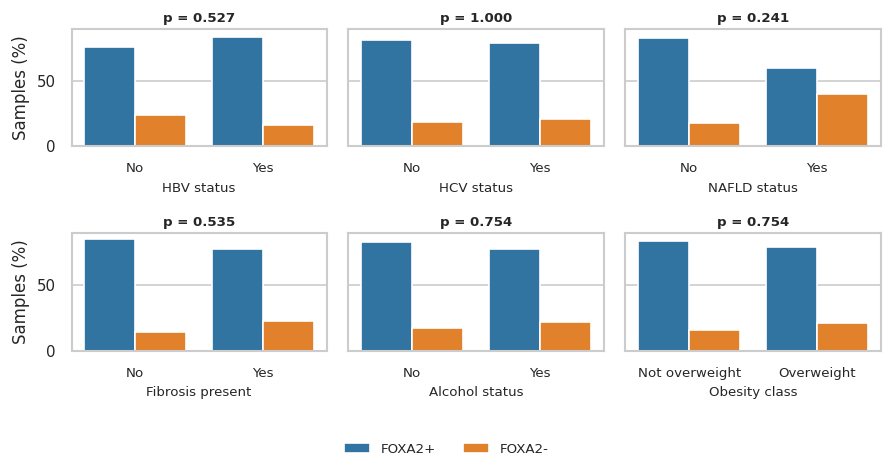

In [3]:
label_specs = [
    ('hbv_status', ['no', 'yes'], ['No', 'Yes'], 'HBV status'),
    ('hcv_status', ['no', 'yes'], ['No', 'Yes'], 'HCV status'),
    ('nafld_status', ['no', 'yes'], ['No', 'Yes'], 'NAFLD status'),
    ('fibrosis_present', ['no', 'yes'], ['No', 'Yes'], 'Fibrosis present'),
    ('alcohol_status', ['no', 'yes'], ['No', 'Yes'], 'Alcohol status'),
    ('obesity_binary', ['not_overweight', 'overweight'], ['Not overweight', 'Overweight'], 'Obesity class'),
]

rows = []
plot_rows = []
for var, levels, tick_labels, display_name in label_specs:
    sub = analysis_df[[var, 'assigned_state']].dropna().copy()
    sub[var] = sub[var].astype(str).str.strip().str.lower()
    sub = sub[sub[var].isin(levels)]
    tab = pd.crosstab(sub[var], sub['assigned_state']).reindex(index=levels, columns=STATE_ORDER, fill_value=0)
    if tab.shape == (2, 2):
        _, p_value = fisher_exact(tab)
        test_type = 'fisher_exact'
    else:
        _, p_value, _, _ = chi2_contingency(tab)
        test_type = 'chi2'
    prop = tab.div(tab.sum(axis=1), axis=0)
    rows.append({
        'clinical_variable': var,
        'display_name': display_name,
        'n_total': int(tab.to_numpy().sum()),
        'test_type': test_type,
        'p_value': float(p_value),
        'foxa2_minus_fraction_group0': float(prop.loc[levels[0], 'FOXA2-']),
        'foxa2_minus_fraction_group1': float(prop.loc[levels[1], 'FOXA2-']),
    })
    long = prop.reset_index().melt(id_vars=var, var_name='assigned_state', value_name='fraction')
    long['clinical_variable'] = var
    long['display_name'] = display_name
    long['group_order'] = long[var].map({levels[0]: 0, levels[1]: 1})
    long['group_label'] = long[var].map({levels[0]: tick_labels[0], levels[1]: tick_labels[1]})
    plot_rows.append(long)

label_summary = pd.DataFrame(rows)
label_summary.to_csv(SUMMARY_DIR / '02_label_based_sensitivity_summary_best_setup.csv', index=False)
plot_df = pd.concat(plot_rows, ignore_index=True)
plot_df['pct'] = 100.0 * plot_df['fraction']


def fmt_p(p):
    return 'p < 0.001' if float(p) < 0.001 else f'p = {float(p):.3f}'


fig, axes = plt.subplots(2, 3, figsize=(7.6, 3.9), sharey=True)
axes = axes.flatten()
for i, (ax, (var, levels, tick_labels, display_name)) in enumerate(zip(axes, label_specs)):
    sub = plot_df[plot_df['clinical_variable'] == var]
    sns.barplot(
        data=sub,
        x='group_order',
        y='pct',
        hue='assigned_state',
        hue_order=STATE_ORDER,
        palette=STATE_PALETTE,
        errorbar=None,
        ax=ax,
    )
    p = label_summary.loc[label_summary['clinical_variable'] == var, 'p_value'].iloc[0]
    ax.set_title(fmt_p(p), fontsize=8, fontweight='bold', pad=4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(tick_labels)
    ax.set_xlabel(display_name, fontsize=8)
    ax.set_ylim(0, 90)
    ax.set_ylabel('Samples (%)' if i % 3 == 0 else '')
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(FIG_DIR / '02_label_sensitivity_state_composition.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


## 3) Mutation-Burden-Adjusted Viral Score Associations


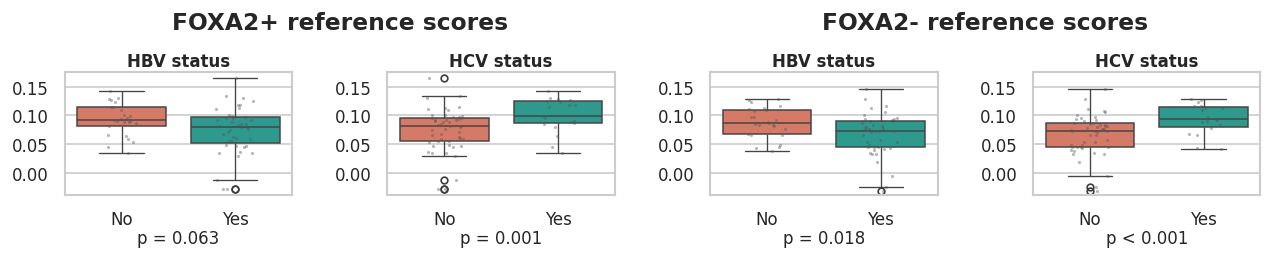

In [4]:
score_specs = [
    ('hbv_status', ['no', 'yes'], ['No', 'Yes'], 'HBV status'),
    ('hcv_status', ['no', 'yes'], ['No', 'Yes'], 'HCV status'),
]


def score_summary(feature_name: str) -> pd.DataFrame:
    test_rows = adj_group_tests_primary[
        (adj_group_tests_primary['score_feature'] == feature_name)
        & (adj_group_tests_primary['test_type'] == 'mannwhitneyu')
    ].copy()
    rows = []
    for var, levels, _, _ in score_specs:
        hit = test_rows[test_rows['metadata_variable'] == var].iloc[0]
        group_summary = json.loads(hit['group_summary_json'])
        effect_summary = json.loads(hit['effect_summary_json'])
        rows.append({
            'clinical_variable': var,
            'n_group0': int(group_summary[levels[0]]['n']),
            'n_group1': int(group_summary[levels[1]]['n']),
            'median_group0_adjusted': float(group_summary[levels[0]]['median']),
            'median_group1_adjusted': float(group_summary[levels[1]]['median']),
            'median_group1_minus_group0_adjusted': float(effect_summary['median_diff_group1_minus_group0']),
            'p_value_mannwhitney_adjusted': float(hit['p_value']),
        })
    return pd.DataFrame(rows)

normal_summary = score_summary('score_foxa2_normal_pos_adj_mutburden')
abnormal_summary = score_summary('score_foxa2_abnormal_zero_adj_mutburden')
normal_summary.to_csv(SUMMARY_DIR / '04_clinical_score_association_normal_summary_best_setup.csv', index=False)
abnormal_summary.to_csv(SUMMARY_DIR / '03_clinical_score_association_summary_best_setup.csv', index=False)

sig_table = pd.concat([
    normal_summary[normal_summary['p_value_mannwhitney_adjusted'] < 0.05].assign(track='FOXA2+ score'),
    abnormal_summary[abnormal_summary['p_value_mannwhitney_adjusted'] < 0.05].assign(track='FOXA2- score'),
], ignore_index=True)
sig_table.to_csv(SUMMARY_DIR / '05_significant_clinical_results_both_tracks_best_setup.csv', index=False)


def fmt_p(p):
    return 'p < 0.001' if float(p) < 0.001 else f'p = {float(p):.3f}'


def draw_score_panel(ax, var, score_col, summary_df):
    levels, tick_labels = ['no', 'yes'], ['No', 'Yes']
    sub = analysis_df[[var, score_col]].dropna().copy()
    sub[var] = sub[var].astype(str).str.strip().str.lower()
    sub = sub[sub[var].isin(levels)]
    sns.boxplot(
        data=sub,
        x=var,
        y=score_col,
        order=levels,
        hue=var,
        hue_order=levels,
        palette=[GROUP_PALETTE[l] for l in levels],
        linewidth=0.9,
        width=0.78,
        fliersize=4,
        saturation=0.95,
        legend=False,
        ax=ax,
        boxprops={'edgecolor': '#444444'},
        medianprops={'color': '#444444', 'linewidth': 0.9},
        whiskerprops={'color': '#444444', 'linewidth': 0.8},
        capprops={'color': '#444444', 'linewidth': 0.8},
    )
    sns.stripplot(
        data=sub,
        x=var,
        y=score_col,
        order=levels,
        color='#555555',
        alpha=0.42,
        size=1.9,
        jitter=0.17,
        ax=ax,
    )
    p = summary_df.loc[summary_df['clinical_variable'] == var, 'p_value_mannwhitney_adjusted'].iloc[0]
    ax.set_title('HBV status' if var == 'hbv_status' else 'HCV status', fontsize=10, fontweight='bold', pad=4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.set_xlabel(fmt_p(p), labelpad=18, fontsize=10)
    ax.xaxis.set_label_coords(0.5, -0.28)
    ax.set_ylabel('')
    ax.set_ylim(-0.038, 0.175)
    ax.set_yticks([0.00, 0.05, 0.10, 0.15])
    ax.tick_params(axis='y', labelsize=10)


fig, axes = plt.subplots(1, 4, figsize=(10.6, 2.55), sharey=False)
layout = [
    ('hbv_status', 'score_foxa2_normal_pos', normal_summary),
    ('hcv_status', 'score_foxa2_normal_pos', normal_summary),
    ('hbv_status', 'score_foxa2_abnormal_zero', abnormal_summary),
    ('hcv_status', 'score_foxa2_abnormal_zero', abnormal_summary),
]
for ax, (var, score_col, summary_df) in zip(axes, layout):
    draw_score_panel(ax, var, score_col, summary_df)

fig.subplots_adjust(left=0.055, right=0.995, bottom=0.38, top=0.78, wspace=0.42)
pos = [ax.get_position() for ax in axes]
fig.text((pos[0].x0 + pos[1].x1) / 2, 0.98, 'FOXA2+ reference scores', ha='center', va='top', fontsize=14, fontweight='bold')
fig.text((pos[2].x0 + pos[3].x1) / 2, 0.98, 'FOXA2- reference scores', ha='center', va='top', fontsize=14, fontweight='bold')
fig.savefig(FIG_DIR / '03_clinical_boxplots_adjusted_scores_by_viral_status.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


## 4) Overall Survival by FOXA2 Reference-Alignment Label


/tmp/ipykernel_109527/1753659879.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


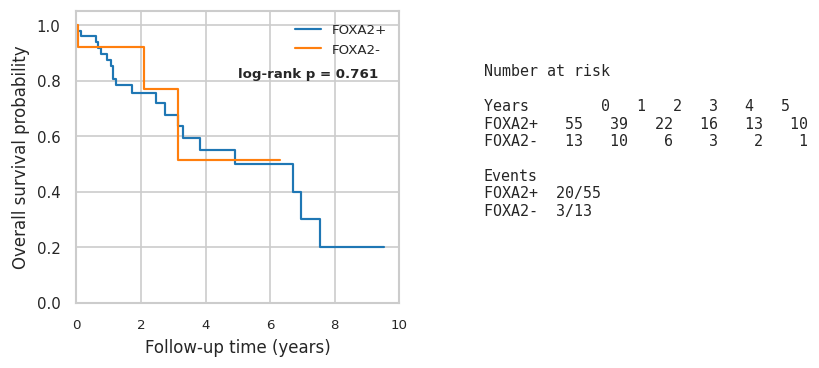

Number at risk

Years        0   1   2   3   4   5
FOXA2+   55   39   22   16   13   10
FOXA2-   13   10    6    3    2    1

Events
FOXA2+  20/55
FOXA2-  3/13


In [5]:
surv_df = analysis_df[['assigned_state', 'time_years', 'event']].dropna().copy()


def km_curve(frame: pd.DataFrame) -> tuple[list[float], list[float]]:
    frame = frame.sort_values('time_years')
    event_times = np.sort(frame.loc[frame['event'], 'time_years'].unique())
    xs = [0.0]
    ys = [1.0]
    survival = 1.0
    for t in event_times:
        at_risk = int((frame['time_years'] >= t).sum())
        events = int(((frame['time_years'] == t) & frame['event']).sum())
        xs.extend([float(t), float(t)])
        ys.extend([survival, survival * (1.0 - events / at_risk)])
        survival = ys[-1]
    xs.append(float(frame['time_years'].max()))
    ys.append(survival)
    return xs, ys

summary = []
for state in STATE_ORDER:
    sub = surv_df[surv_df['assigned_state'] == state]
    summary.append({
        'assigned_state': state,
        'n_samples': len(sub),
        'n_events': int(sub['event'].sum()),
        'median_follow_up_years': float(sub['time_years'].median()),
        'median_survival_years': np.nan,
        'logrank_statistic': 0.09273,
        'logrank_p_value': 0.760734,
    })
pd.DataFrame(summary).to_csv(SUMMARY_DIR / '06_overall_survival_by_state_summary_best_setup.csv', index=False)

fig = plt.figure(figsize=(7.4, 3.15))
gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1.0], wspace=0.28)
ax = fig.add_subplot(gs[0, 0])
ax_table = fig.add_subplot(gs[0, 1])
for state in STATE_ORDER:
    sub = surv_df[surv_df['assigned_state'] == state]
    xs, ys = km_curve(sub)
    ax.step(xs, ys, where='post', color=STATE_PALETTE[state], linewidth=1.3, label=state)
ax.set_xlim(0, 10)
ax.set_ylim(0, 1.05)
ax.set_xlabel('Follow-up time (years)')
ax.set_ylabel('Overall survival probability')
ax.legend(frameon=False, loc='upper right')
ax.text(5.0, 0.825, 'log-rank p = 0.761', fontsize=8, fontweight='bold', ha='left', va='center')

ax_table.axis('off')
years = list(range(6))
risk_lines = ['Number at risk', '', 'Years        ' + '   '.join(str(y) for y in years)]
for state in STATE_ORDER:
    sub = surv_df[surv_df['assigned_state'] == state]
    counts = [int((sub['time_years'] >= y).sum()) for y in years]
    risk_lines.append(f"{state:<7} " + '  '.join(f'{x:>3}' for x in counts))
risk_lines.extend(['', 'Events'])
for state in STATE_ORDER:
    sub = surv_df[surv_df['assigned_state'] == state]
    risk_lines.append(f"{state:<7} {int(sub['event'].sum())}/{len(sub)}")
risk_text = '\n'.join(risk_lines)
ax_table.text(0.0, 0.82, risk_text, transform=ax_table.transAxes, ha='left', va='top', family='monospace', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / '04_overall_survival_by_foxa2_state.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(risk_text)


## Figure Manifest

In [6]:
figs = sorted(FIG_DIR.glob('*.png'))
for f in figs:
    print(f.name)
print(f'\nTotal figures: {len(figs)}')

summary_files = sorted(SUMMARY_DIR.glob('*.csv'))
for f in summary_files:
    print(f.name)
print(f'\nTotal summary tables: {len(summary_files)}')


01_state_distribution_selected_setup.png
02_label_sensitivity_state_composition.png
03_clinical_boxplots_adjusted_scores_by_viral_status.png
04_overall_survival_by_foxa2_state.png

Total figures: 4
01_state_distribution_best_setup.csv
02_label_based_sensitivity_summary_best_setup.csv
03_clinical_score_association_summary_best_setup.csv
04_clinical_score_association_normal_summary_best_setup.csv
05_significant_clinical_results_both_tracks_best_setup.csv
06_overall_survival_by_state_summary_best_setup.csv
source_clinical_labels.csv
source_validation_group_tests_mutation_burden_adjusted.csv
source_validation_score_rankings.csv

Total summary tables: 9
